In [2]:
# python -m venv venv
# venv\Scripts\activate    # Windows

# pip install ipykernel jupyter
# python -m ipykernel install --user --name=venv --display-name="Python (venv)"

# pip install -r requirements.txt

In [ ]:
# pip install langgraph langchain_openai langchain_core python-dotenv fastapi langchain-community langchain-google-genai langchain_groq
# pip install groq

# pip list 
# pip show langgraph langchain_openai langchain_core python-dotenv fastapi langchain-community langchain-google-genai

In [4]:
import sys
print(sys.executable)

c:\Users\Charlie\AI\GEN_AI\capstone_projects\perplexity_clone\server\venv\Scripts\python.exe


In [ ]:
# !pip install langchain_groq

  Using cached langchain_groq-1.1.3-py3-none-any.whl.metadata (2.9 kB)
  Using cached groq-0.37.1-py3-none-any.whl.metadata (16 kB)
Using cached langchain_groq-1.1.3-py3-none-any.whl (20 kB)
Using cached groq-0.37.1-py3-none-any.whl (137 kB)
  Attempting uninstall: groq
    Found existing installation: groq 1.5.0
    Uninstalling groq-1.5.0:
      Successfully uninstalled groq-1.5.0



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from typing import TypedDict, Annotated, Optional
from langgraph.graph import add_messages,StateGraph,END
from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.checkpoint.memory import MemorySaver
from uuid import uuid4
import json


C:\Users\Charlie\AppData\Local\Temp\ipykernel_4124\3573173075.py:7: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


In [4]:

# import os


load_dotenv()

# model = ChatGoogleGenerativeAI(model="gemini-3.5-flash", google_api_key=os.getenv("GEMINI_API_KEY"),temperature=0.2, max_output_tokens=1024)\
# client = Groq(api_key=os.getenv("GROQ_API_KEY"))
model = ChatGroq(
    # api_key=os.getenv("GROQ_API_KEY"),
    # api_key=GROQ_API_KEY,
    model="llama-3.1-8b-instant",
    temperature=0.2
)

In [5]:
search_tool = TavilySearchResults(max_results=3)

tools = [search_tool]

memory = MemorySaver()

C:\Users\Charlie\AppData\Local\Temp\ipykernel_4124\270826979.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search_tool = TavilySearchResults(max_results=3)


In [6]:
llm_with_tools = model.bind_tools(tools=tools)

In [7]:
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage

class State(TypedDict):
    messages: Annotated[list,add_messages]

async def model(state: State):
    messages = state["messages"]
    response = await llm_with_tools.ainvoke(messages)
    return {
        "messages": [response]
    }

async def tools_router(state: State):
    last_message = state["messages"][-1]
    if(hasattr(last_message,"tool_calls") and len(last_message.tool_calls) > 0):
        return "tool_node"
    else:
        return END
    
async def tool_node(state):
    """Custom tool node that handles tool calls from the LLM."""
    # Get the tool calls from the last message
    tool_calls = state["messages"][-1].tool_calls

    tool_messages = []
    for tool_call in tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]
        tool_id = tool_call["id"]

        # handle the search tool
        if tool_name == "tavily_search_results_json":
            search_results = await search_tool.ainvoke(tool_args)
            tool_messages.append(ToolMessage(
                content=json.dumps(search_results),
                # tool_name=tool_name,
                # tool_args=tool_args,
                tool_call_id=tool_id
            ))
        else:
            raise ValueError(f"Unknown tool: {tool_name}")
    
    return {
        "messages": tool_messages  
    }

In [8]:
graph_builder = StateGraph(State)

graph_builder.add_node("model", model)
graph_builder.add_node("tool_node", tool_node)

graph_builder.set_entry_point("model")
graph_builder.add_conditional_edges(
    "model",
    tools_router,
    {
        "tool_node": "tool_node",
        END: END,
    }
)
graph_builder.add_edge("tool_node", "model")

graph = graph_builder.compile(checkpointer=memory)

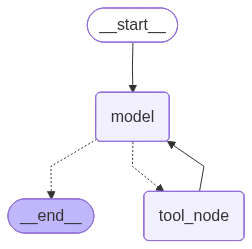

In [9]:
from IPython.display import Image, display, Markdown
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API
            )
    )
)

In [10]:
print(graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	model(model)
	tool_node(tool_node)
	__end__([<p>__end__</p>]):::last
	__start__ --> model;
	model -.-> __end__;
	model -.-> tool_node;
	tool_node --> model;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [11]:
response = await llm_with_tools.ainvoke(
    [HumanMessage(content="What is the latest Java version?")]
)

print(response)
print(response.tool_calls)
import json

response_json = {
    "content": response.content,
    "tool_calls": response.tool_calls,
    "invalid_tool_calls": response.invalid_tool_calls,
    "response_metadata": response.response_metadata,
    "usage_metadata": response.usage_metadata,
    "id": response.id
}

print(json.dumps(response_json, indent=4))

content='' additional_kwargs={'tool_calls': [{'id': 's5ak4m68d', 'function': {'arguments': '{"query":"latest Java version"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 285, 'total_tokens': 305, 'completion_time': 0.030198291, 'completion_tokens_details': None, 'prompt_time': 0.019535962, 'prompt_tokens_details': None, 'queue_time': 0.048166941, 'total_time': 0.049734253}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019f024f-9c17-7162-b5b5-7a4c539e6587-0' tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'latest Java version'}, 'id': 's5ak4m68d', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 285, 'output_tokens': 20, 'total_tokens': 305}
[{'name': 'tavily_search_results_json', 'args': {'query': 'la

In [12]:
config = {
    "configurable": {
        "thread_id": 6
    }
}
response = await graph.ainvoke({
# "messages": [HumanMessage(content="What is the latest Java version?")],
# "messages": [HumanMessage(content="How are you?")] , 
# "messages": [HumanMessage(content="I am Mr.Curious")]
"messages": [HumanMessage(content="Is Gen AI jobs are booming?")]
}, config=config)
print(response)


{'messages': [HumanMessage(content='Is Gen AI jobs are booming?', additional_kwargs={}, response_metadata={}, id='be39f18d-81a0-4ae6-99ca-87c7ebff0e1b'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'axxyxhp57', 'function': {'arguments': '{"query":"Gen AI jobs booming"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 285, 'total_tokens': 306, 'completion_time': 0.030594357, 'completion_tokens_details': None, 'prompt_time': 0.01736658, 'prompt_tokens_details': None, 'queue_time': 0.054552955, 'total_time': 0.047960937}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f024f-e02a-7e92-9fd2-44545113851f-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Gen AI jobs booming'}, 'id': 'axxyxhp57', 'type': 'tool_cal

In [13]:
import json
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage, SystemMessage

def message_to_dict(msg):
    if isinstance(msg, HumanMessage):
        return {
            "type": "HumanMessage",
            "content": msg.content
        }

    elif isinstance(msg, AIMessage):
        return {
            "type": "AIMessage",
            "content": msg.content,
            "tool_calls": msg.tool_calls,
            "usage_metadata": msg.usage_metadata,
            "response_metadata": msg.response_metadata
        }

    elif isinstance(msg, ToolMessage):
        return {
            "type": "ToolMessage",
            "content": msg.content,
            "tool_call_id": msg.tool_call_id
        }

    elif isinstance(msg, SystemMessage):
        return {
            "type": "SystemMessage",
            "content": msg.content
        }

    else:
        return str(msg)


pretty_response = {
    "messages": [
        message_to_dict(message)
        for message in response["messages"]
    ]
}

print(json.dumps(pretty_response, indent=4))

{
    "messages": [
        {
            "type": "HumanMessage",
            "content": "Is Gen AI jobs are booming?"
        },
        {
            "type": "AIMessage",
            "content": "",
            "tool_calls": [
                {
                    "name": "tavily_search_results_json",
                    "args": {
                        "query": "Gen AI jobs booming"
                    },
                    "id": "axxyxhp57",
                    "type": "tool_call"
                }
            ],
            "usage_metadata": {
                "input_tokens": 285,
                "output_tokens": 21,
                "total_tokens": 306
            },
            "response_metadata": {
                "token_usage": {
                    "completion_tokens": 21,
                    "prompt_tokens": 285,
                    "total_tokens": 306,
                    "completion_time": 0.030594357,
                    "completion_tokens_details": null,
                

In [ ]:
# import os
# from dotenv import load_dotenv

# load_dotenv()

# print(os.getenv("TAVILY_API_KEY"))

In [21]:
result = await search_tool.ainvoke(
    {"query": "whaen did SpaceX lunch  ?"}
)

print(result)

[{'title': 'History of SpaceX - Wikipedia', 'url': 'https://en.wikipedia.org/wiki/History_of_SpaceX', 'content': 'was quickly resolved by a supply drop of chicken wings and cigarettes.:\u200a71–77 [...] On May 23, 2019, SpaceX deployed the first 60 of around 12,000 satellites in its planned Starlink satellite system – which it aimed to use to provide low latency network communications via a large constellation in low Earth orbit (LEO).\n\nOn May 30, 2020, SpaceX launched two NASA astronauts (Douglas Hurley and Robert Behnken) into orbit on a Crew Dragon spacecraft during SpaceX Demo-2, making SpaceX the first private company to send astronauts to the International Space Station (ISS) and marking the first crewed launch from American soil in 9 years. The mission launched from Launch Complex 39A of the Kennedy Space Center in Florida. SpaceX Demo-2 successfully docked with the ISS on May 31, 2020 and returned the astronauts safely on August 2, 2020. [...] In August 2012, SpaceX signed a 

In [22]:
print(json.dumps(result, indent=4))

[
    {
        "title": "History of SpaceX - Wikipedia",
        "url": "https://en.wikipedia.org/wiki/History_of_SpaceX",
        "content": "was quickly resolved by a supply drop of chicken wings and cigarettes.:\u200a71\u201377 [...] On May 23, 2019, SpaceX deployed the first 60 of around 12,000 satellites in its planned Starlink satellite system \u2013 which it aimed to use to provide low latency network communications via a large constellation in low Earth orbit (LEO).\n\nOn May 30, 2020, SpaceX launched two NASA astronauts (Douglas Hurley and Robert Behnken) into orbit on a Crew Dragon spacecraft during SpaceX Demo-2, making SpaceX the first private company to send astronauts to the International Space Station (ISS) and marking the first crewed launch from American soil in 9 years. The mission launched from Launch Complex 39A of the Kennedy Space Center in Florida. SpaceX Demo-2 successfully docked with the ISS on May 31, 2020 and returned the astronauts safely on August 2, 2020

In [ ]:
# import os

# search = TavilySearchResults(
#     max_results=2,
#     tavily_api_key=os.getenv("TAVILY_API_KEY")
# )

In [15]:
config = {
    "configurable": {  
        
        "thread_id": 6
    }       
}
async for event in graph.astream_events({
    "messages": [HumanMessage(content="What is the capital of France?")]
},config=config):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={})]}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019f0250-9e36-7c12-9455-cc9c0b3419af', 'metadata': {'thread_id': 6, 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Is Gen AI jobs are booming?', additional_kwargs={}, response_metadata={}, id='be39f18d-81a0-4ae6-99ca-87c7ebff0e1b'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'axxyxhp57', 'function': {'arguments': '{"query":"Gen AI jobs booming"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 285, 'total_tokens': 306, 'completion_time': 0.030594357, 'completion_tokens_details': None, 'prompt_time': 0.01736658, 'prompt_tokens_details': None, 'queue_time': 0.054552955, 'total_time': 0.04796